## **CSMODEL S10A, Group 4: Balikbayan Babes**
**Co**, Alphonso Rian; **Guarin**, Raine Louise; **Maravilla**, Sofia; **Melanio**, Marion Zane; **Pasigan**, Maria Elisa

## **ABSTRACT**

This study utilizes data from the International Social Survey Programme (ISSP) Social Inequality I–V Cumulation dataset, comprising 157,446 respondents across multiple countries and time periods, to examine factors associated with perceived social inequality. With 106 columns containing categorical data from the close-ended questionnaire and interview questions, the variables tackle on the participants' subjective perception on the socio-demographic features towards their social class.

Using the factors measured in the study, we focused on measuring the gap between subjective and objective class rank, finding correlation and ranking of different variables with the gap, and the measuring income against the variables with the highest rank of correlation with said gap. There are four theories used to rationalize: Subjective Social Theory, Bourdieu's Theory of Capital, Social Comparison Theory, and Relative Deprivation Theory.

It is notable that many of the variables have categories involving a category of 'No answer', some instances were not included when measuring relationships between variables. Results indicate that discrepancies between subjective and objective class rankings were present across all observations, with the smallest observed discrepancy rate being 8.24%. For finding correlation, there was a strong negative correlation with income due to how the categories were normalized, a negative correlation with age where the perception of the age is inversely proportional to gap, and a positive correlation with the household population where the bigger the household, the bigger the gap. Income exhibited the strongest association with the class-rank gap, whereas sex demonstrated the weakest association. The four theories explained that the gap is prominent in people with higher education degrees, the employed, and low population households.

## **DATASET DESCRIPTION**

The dataset International Social Survey Programme: Social Inequality I-V Cumulation explores the different social backgrounds from different countries that determine the personal success in society. Such factors are family, race, talents, skills, ambition, religion, and education.  

The population was sampled varyingly from country to country from simple random sampling to multistage sampling, producing results to over 157446 instances. To collect numeric data, many of the data collectors from multiple countries used self-administered closed-ended questionnaires (paper and web-based), interviews (computer-assisted and paper-and-pencil face-to-face, web-based, telephone) data collection instruments. Researchers made sure sampling reflected the country's population as expressed by its WEIGHT variable. It is notable that populations vary from country to country.

Each of the 157446 instances are analyzed individually, meaning, each row represents a person and their personal background. The 106 columns represent the attributes the person should have defined by the research, and the questions involved in the survey/interview. Atrributes stored are used for identification (GESIS archive no., DOI, ID of the respondent, year, country), personal information (age, sex, education, occupation), and the different factors that affected their daily lives (n. members of the household, voting history, supported political parties).

## **DATA CLEANING AND PREPROCESSING**

The code below involves fixing the format for all involved columns, and grouping values to lessen categories. Since the data type was categorical for all columns, excluding cumu_id, they were all fixed to contain strings for ease of using replace and loc. Missing values were grouped together with the category "No answer". No values were dropped.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math as m
import seaborn as sns

dataframe = pd.read_stata("social_inequality.dta")

## Dropping Unnecessary Columns

In [2]:
cols_to_drop = [f"v{i}" for i in range(1,72)]
new_df = dataframe.drop(columns=cols_to_drop)
cols_to_drop = ['version', 'doi', 'studyno', 'caseid', 'c_sample', 'c_sample_year', 'PRTY_LR1', 'PRTY_LR2', 'VOTE_LE', 'VOTE_LR', 'WEIGHT', 'COHAB',
                'EDUCYRS', 'ISCO88', 'SELFEMP', 'WRKSUP', 'UNION', 'SPMAINST', 'SPISCO88', 'SPSELFEM', 'CHILDHH', 'ATTEND', 'WRKHRS']
new_df = new_df.drop(columns=cols_to_drop)

## Formatting The Year to XXXX

In [3]:
new_df['year'] = new_df['year'].str.extract(r'^(\d{4})')
new_df['year'].value_counts()

year
2009    44578
2019    42441
1999    31181
1992    23900
1987    15346
Name: count, dtype: int64

##

In [4]:
new_df['country'] = new_df['country'].astype(str)
new_df['country'] = new_df['country'].str.extract(r'\.\s*([A-Z]{2})-')
new_df['country'].value_counts()

country
DE    8940
AU    8131
PL    7971
PH    7850
US    7542
RU    6888
FR    6304
HU    6074
ZA    6032
GB    5764
CZ    5641
NO    5375
AT    5276
CH    5258
SE    4672
NZ    4492
CL    4382
BG    4380
IT    4322
SI    4284
JP    4094
TW    3952
IL    3602
SK    2663
DK    2556
ES    2426
HR    2201
IS    2174
LV    2169
PT    2144
VE    2088
LT    2073
CA    1976
CY    1904
FI    1846
Name: count, dtype: int64

## Formatting Sex to Male and Female

In [5]:
new_df['SEX'] = new_df['SEX'].astype(str)
new_df['SEX'] = new_df['SEX'].replace({
    '1. Male': 'Male',
    '2. Female': 'Female',
    '-9. No Answer, refused': 'No answer'
})
new_df.dropna(subset=['SEX'])
new_df['SEX'].value_counts()

SEX
Female       83852
Male         73351
No answer      243
Name: count, dtype: int64

## Categorizing Age Ranges to Minor, Young Adult, Adult, Middle-aged Adult, and Senior Citizen

In [6]:
pd.set_option('display.max_rows', None)
new_df['AGE'] = new_df['AGE'].astype(str)
new_df['AGE'] = new_df["AGE"].replace({
    "-9. No Answer, Don't know, refused": 'No answer',
    "15. 15 Years": '15',
    '105. 105 Years': '105'
})
new_df = new_df.dropna(subset=['AGE'])
new_df['AGE'] = pd.to_numeric(new_df['AGE'], errors='coerce')
new_df['AGE_GROUP'] = pd.cut(
    new_df['AGE'],
    bins=[0, 17, 24, 44, 64, 150],
    labels=[
        'Minor',
        'Young Adult',
        'Adult',
        'Middle-aged Adult',
        'Senior Citizen'
    ]
)

new_df['AGE_GROUP'].value_counts()

AGE_GROUP
Adult                57358
Middle-aged Adult    53785
Senior Citizen       28516
Young Adult          16350
Minor                  647
Name: count, dtype: int64

## Categorizing Marital Status to Single, Married and Previously Married

In [7]:
new_df['MARITAL'] = new_df['MARITAL'].astype(str)
new_df['MARITAL'] = new_df["MARITAL"].replace({
    "1. Married, Civil Partnership": "Married",
    "5. Never married, single": 'Single',
})
new_df.loc[
    new_df['MARITAL'].isin(
        ['2. Widowed', '3. Divorced', '4. Separated (married but sep./not living w legal spouse)']
    ),
    'MARITAL'
] = 'Previously Married'
new_df.loc[
    new_df['MARITAL'].isin(
        ['-1. Variable not available for this country in this module', '-9. No Answer, refused', '-7. Refused']
    ),
    'MARITAL'
] = 'No answer'
new_df['MARITAL'].value_counts()

MARITAL
Married               87868
Single                37771
Previously Married    26490
No answer              5317
Name: count, dtype: int64

## Categorizing Degree

In [8]:
new_df['DEGREE'] = new_df['DEGREE'].astype(str)
new_df['DEGREE'] = new_df['DEGREE'].replace({
    '3. Higher secondary completed': 'Higher secondary',
    '2. Above lowest qualification': 'Above lowest',
    '5. University degree completed, graduate studies': 'Graduate studies',
    '1. Lowest formal qualification': 'Lowest formal',
    '4. Above higher secondary level': 'Above higher secondary',
    '0. No formal qualification': 'No formal qualification',
    "-9. NA, DK, can't choose, other": 'No answer'
})
new_df['DEGREE'].value_counts()

DEGREE
Higher secondary           39569
Above lowest               34718
Graduate studies           30910
Lowest formal              21820
Above higher secondary     19602
No formal qualification     9389
No answer                   1438
Name: count, dtype: int64

## Categorizing Employement

In [9]:
new_df['MAINSTAT'] = new_df['MAINSTAT'].astype(str)
new_df['MAINSTAT'] = new_df['MAINSTAT'].replace({
    '1. In paid work': 'Employed',
    '5. Retired': 'Retired',
    '2. Unemployed and looking for a job': 'Unemployed',
    '-4. NAP, never had paid work': 'Unemployed',
    '6. Domestic work': 'Domestic work',
    '3. In education / Apprentice or trainee': 'Apprentice or trainee',
    '4. Permanently sick or disabled': 'Sick or disabled'
})
new_df.loc[
    new_df['MAINSTAT'].isin(
        ['8. Other', '7. In compulsory military service or community service']
    ),
    'MAINSTAT'
] = 'Other'
new_df.loc[
    new_df['MAINSTAT'].isin(
        ['-1. Variable not available for this country in this module', '-9. No Answer', "-8. Don't know", '-7. Refused']
    ),
    'MAINSTAT'
] = 'No answer'
new_df['MAINSTAT'].value_counts()

MAINSTAT
Employed                 84304
Retired                  29316
Domestic work            10260
Unemployed               10056
Other                     7358
Apprentice or trainee     7338
No answer                 6262
Sick or disabled          2552
Name: count, dtype: int64

## Categorizing Home Population

In [10]:
new_df['HOMPOP'] = new_df['HOMPOP'].astype(str)
new_df['HOMPOP'] = new_df['HOMPOP'].replace({
    '1. 1 person': '1',
    '-1. Variable not available for this country in this module': 'No answer',
    '-9. No Answer, refused': 'No answer',
    '-4. NAP, not a private household': 'No answer',
    '44. 44 persons': '44'
})
new_df = new_df.dropna(subset=['HOMPOP'])
new_df['HOMPOP'].value_counts()

HOMPOP
2            43377
4            29526
3            28625
1            23218
5            13596
No answer     7845
6             5990
7             2533
8             1282
9              661
10             333
11             187
12             121
13              57
14              28
15              18
16              13
18              10
17               9
19               5
25               3
20               3
23               2
22               2
44               1
40               1
Name: count, dtype: int64

## Categorizing Religion

In [11]:
new_df['RELIGGRP'] = new_df['RELIGGRP'].astype(str)
new_df.loc[
    new_df['RELIGGRP'].isin(
        ['2. Roman Catholic', '3. Protestant', '4. Christian Orthodox', '9. Other Christian Religions', '96. No (Christian) denomination given']
    ),
    'RELIGGRP'
] = 'Christian'
new_df['RELIGGRP'] = new_df['RELIGGRP'].replace({
    '1. No religion': 'No religion',
    '5. Jewish': 'Jewish',
    '6. Islam': 'Islam',
    '7. Buddhism': 'Buddhism'
})
new_df.loc[
    new_df['RELIGGRP'].isin(
        ['10. Other Eastern/Asian Religions', '11. Other Religions', '8. Hinduism']
    ),
    'RELIGGRP'
] = 'Other'
new_df.loc[
    new_df['RELIGGRP'].isin(
        ['-1. Variable not available for this country in this module', '-9. No Answer, refused', "-8. Don't know", '-7. Refused']
    ),
    'RELIGGRP'
] = 'No answer'
new_df['RELIGGRP'].value_counts()

RELIGGRP
Christian      104299
No religion     31155
No answer        9656
Other            4017
Jewish           3373
Islam            2547
Buddhism         2399
Name: count, dtype: int64

## Categorizing Subjective Class Rank

In [12]:
new_df['TOPBOT'] = new_df['TOPBOT'].astype(str)
new_df['TOPBOT'] = new_df['TOPBOT'].replace({
    '1. Bottom, Lowest, 01': '1',
    '2. 02': '2',
    '3. 03': '3',
    '4. 04': '4',
    '5. 05': '5',
    '6. 06': '6',
    '7. 07': '7',
    '8. 08': '8',
    '9. 09': '9',
    '10. Top, Highest, 10': '10'
})
new_df.loc[
    new_df['TOPBOT'].isin(
        ['-9. No Answer', "-8. Don't know, can't choose", '-7. Refused']
    ),
    'TOPBOT'
] = 'No answer'
new_df['TOPBOT'].value_counts()

TOPBOT
6            37669
5            33442
4            21039
7            19607
3            15376
8             9552
2             7371
1             6240
No answer     3906
9             1962
10            1282
Name: count, dtype: int64

## Categorizing Objective Class Rank

In [13]:
new_df['INCOME'] = new_df['INCOME'].astype(str)
new_df['INCOME'] = new_df['INCOME'].replace({
    '1. Low': 'Low',
    '2. Middle': 'Middle',
    '3. High': 'High',
    '-9. No Answer': 'No answer',
    '-1. Variable not available for this country in this module': 'No answer',
    '-7. Refused': 'No answer',
    "-8. Don't know": 'No answer'
})
new_df['INCOME'].value_counts()

INCOME
High         42947
Low          42461
Middle       41389
No answer    30649
Name: count, dtype: int64

## **RESEARCH QUESTION AND EXPLORATORY DATA ANALYSIS**

This project focuses on the question: 

***"What are the different socio-demographic features (age, race, sex, marital status, religion, education, employment, household size) maximize the gap between an individual's objective income rank and their subjective social class identification?"***

To achieve a clear answer, the following EDA must be addressed:
1. **Is there a misperception of objective and subjective class rank?**
2. **Is there a correlation between the features, income rank and social class identification?**
3. **What is the rank of the features when it comes to influence?**
4. **How does the magnitude of the income-class gap vary across different income levels when analyzed through the most significant socio-demographic features?**

Discrepancies with objective and subjective rank, and the effects of the features can be explained by the Subjective Social Status Theory, Bourdieu's Theory of Capital, and Social Comparison Theory. 
- Subjective Social Status Theory states that the perceived rank of status is a cause and a consequence of their physical and mental health [4]. 
- Bourdieu's Theory of Capital states that social capital does not come solely from capital gain, but from social network [2].
- Social Comparison Theory states that an individual's perception of their rank is a reflection of the status of their connections and environment [1]. 
- Social Movement Theory: Relative Deprivation Theory states that working with people objectively can make the individual underestimate their rank [3].

## **Gap Between Income and Social Class**

In [14]:
research_q1 = new_df[['TOPBOT', 'INCOME']]
research_q1.info()

<class 'pandas.DataFrame'>
RangeIndex: 157446 entries, 0 to 157445
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   TOPBOT  157446 non-null  str  
 1   INCOME  157446 non-null  str  
dtypes: str(2)
memory usage: 2.4 MB


## Removing the rows with 'No answer' in both TOPBOT and INCOME

In [15]:
research_q1=research_q1[research_q1['INCOME'] != 'No answer']
research_q1=research_q1[research_q1['TOPBOT'] != 'No answer']

In [16]:
research_q1['INCOME'].value_counts()

INCOME
High      42383
Low       41471
Middle    40698
Name: count, dtype: int64

In [17]:
research_q1['TOPBOT'].value_counts()

TOPBOT
6     30454
5     26602
4     17076
7     16240
3     12565
8      7971
2      6035
1      4959
9      1635
10     1015
Name: count, dtype: int64

## Converting the INCOME data to numbers
1 = High Income

2 = Middle Income

3 = Low Income


In [18]:
research_q1['INCOME']=research_q1['INCOME'].replace({
    'High':1,
    'Middle':2,
    'Low':3
})

research_q1['INCOME'].value_counts()

INCOME
1    42383
3    41471
2    40698
Name: count, dtype: int64

In [19]:
research_q1.head(10)

,TOPBOT,INCOME
1198,1,1
1199,2,3
1200,5,1
1201,2,2
1202,1,2
1203,7,2
1204,6,1
1205,6,1
1206,4,1
1207,4,1


## Converting the TOPBOT data to numbers

In [20]:
research_q1['TOPBOT'] = research_q1['TOPBOT'].astype(int)
research_q1['TOPBOT'].info()

<class 'pandas.Series'>
Index: 124552 entries, 1198 to 157445
Series name: TOPBOT
Non-Null Count   Dtype
--------------   -----
124552 non-null  int64
dtypes: int64(1)
memory usage: 1.9 MB


## Percentage between TOPBOT and INCOME per instance

Counting total TOPBOT and INCOME values

In [21]:
total_instances = research_q1.shape[0]
print(total_instances)

124552


## Calculating the gap between TOPBOT and INCOME

What is the ratio of all possible values in the INCOME column?

In [22]:
income_count_1s=research_q1['INCOME'].value_counts().get(1, 0)
income_count_2s=research_q1['INCOME'].value_counts().get(2, 0)
income_count_3s=research_q1['INCOME'].value_counts().get(3, 0)

income_percentages = pd.Series([income_count_1s, income_count_2s, income_count_3s])
print(income_percentages)

0    42383
1    40698
2    41471
dtype: int64


In [23]:
income_percentages=income_percentages / total_instances
print(income_percentages)

0    0.340284
1    0.326755
2    0.332961
dtype: float64


Wherein the higher the number, the denser the instances answered that income class rank.

What is the ratio of all possible values in the TOPBOT column?

In [24]:
topbot_count_1s=research_q1['TOPBOT'].value_counts().get(1, 0)
topbot_count_2s=research_q1['TOPBOT'].value_counts().get(2, 0)
topbot_count_3s=research_q1['TOPBOT'].value_counts().get(3, 0)
topbot_count_4s=research_q1['TOPBOT'].value_counts().get(4, 0)
topbot_count_5s=research_q1['TOPBOT'].value_counts().get(5, 0)
topbot_count_6s=research_q1['TOPBOT'].value_counts().get(6, 0)
topbot_count_7s=research_q1['TOPBOT'].value_counts().get(7, 0)
topbot_count_8s=research_q1['TOPBOT'].value_counts().get(8, 0)
topbot_count_9s=research_q1['TOPBOT'].value_counts().get(9, 0)
topbot_count_10s=research_q1['TOPBOT'].value_counts().get(10, 0)

In [25]:
topbot_percentages = pd.Series([topbot_count_1s,topbot_count_2s,topbot_count_3s,topbot_count_4s,topbot_count_5s,
                      topbot_count_6s,topbot_count_7s,topbot_count_8s,topbot_count_9s,topbot_count_10s])
print(topbot_percentages)

0     4959
1     6035
2    12565
3    17076
4    26602
5    30454
6    16240
7     7971
8     1635
9     1015
dtype: int64


In [26]:
topbot_percentages = topbot_percentages / total_instances
print(topbot_percentages)

0    0.039815
1    0.048454
2    0.100882
3    0.137099
4    0.213581
5    0.244508
6    0.130387
7    0.063997
8    0.013127
9    0.008149
dtype: float64


Wherein the higher the value, the more instances ranked themselves with that number.

## Finding the INCOME and TOPBOT percentage per observation

In [27]:
temp_df=research_q1
research_q1['INCOME_PERCENT']=temp_df['INCOME'].replace({
    1: income_percentages[0],
    2: income_percentages[1],
    3: income_percentages[2]
})
research_q1.head(10)

,TOPBOT,INCOME,INCOME_PERCENT
1198,1,1,0.340284
1199,2,3,0.332961
1200,5,1,0.340284
1201,2,2,0.326755
1202,1,2,0.326755
1203,7,2,0.326755
1204,6,1,0.340284
1205,6,1,0.340284
1206,4,1,0.340284
1207,4,1,0.340284


In [28]:
temp_df=research_q1
research_q1['TOPBOT_PERCENT']=temp_df['TOPBOT'].replace({
    1: topbot_percentages[0],
    2: topbot_percentages[1],
    3: topbot_percentages[2],
    4: topbot_percentages[3],
    5: topbot_percentages[4],
    6: topbot_percentages[5],
    7: topbot_percentages[6],
    8: topbot_percentages[7],
    9: topbot_percentages[8],
    10: topbot_percentages[9]
})
research_q1.head(10)

,TOPBOT,INCOME,INCOME_PERCENT,TOPBOT_PERCENT
1198,1,1,0.340284,0.039815
1199,2,3,0.332961,0.048454
1200,5,1,0.340284,0.213581
1201,2,2,0.326755,0.048454
1202,1,2,0.326755,0.039815
1203,7,2,0.326755,0.130387
1204,6,1,0.340284,0.244508
1205,6,1,0.340284,0.244508
1206,4,1,0.340284,0.137099
1207,4,1,0.340284,0.137099


## Getting the difference between INCOME and TOPBOT percentages per observation



In [29]:
research_q1['DIFFERENCE']=research_q1['INCOME_PERCENT']-research_q1['TOPBOT_PERCENT']
research_q1['DIFFERENCE'] = (research_q1['DIFFERENCE'] * 100).round(4)
print(research_q1.head(10))

      TOPBOT INCOME INCOME_PERCENT  TOPBOT_PERCENT DIFFERENCE
1198       1      1       0.340284        0.039815    30.0469
1199       2      3       0.332961        0.048454    28.4508
1200       5      1       0.340284        0.213581    12.6702
1201       2      2       0.326755        0.048454    27.8301
1202       1      2       0.326755        0.039815     28.694
1203       7      2       0.326755        0.130387    19.6368
1204       6      1       0.340284        0.244508     9.5775
1205       6      1       0.340284        0.244508     9.5775
1206       4      1       0.340284        0.137099    20.3184
1207       4      1       0.340284        0.137099    20.3184


Text(0.5, 1.0, 'Distribution of Subjective-Objective Status Gap')

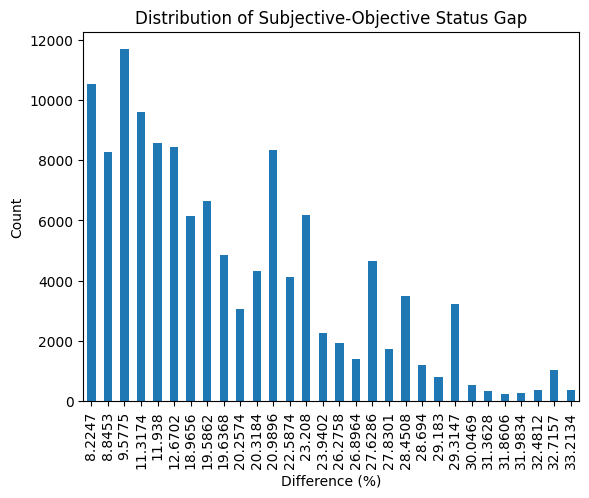

In [30]:
research_q1['DIFFERENCE'].value_counts().sort_index().plot.bar()
plt.xlabel('Difference (%)')
plt.ylabel('Count')
plt.title('Distribution of Subjective-Objective Status Gap')

### **The bigger the difference, the bigger the status misperception where a person perceive their rank differently than their objective class rank. Majority of the people surveyed suffer mild status misperception with the lowest being 8.2247%, meaning they are aware of their rank.**

## **Rank of Features**



### Copying the Dataset to make sure the TOPBOT column is numeric and has no missing values.

In [31]:
eda2_df = new_df.copy()
eda2_df = eda2_df[eda2_df['TOPBOT'] != 'No answer']
eda2_df['TOPBOT'] = pd.to_numeric(eda2_df['TOPBOT'], errors='coerce')
eda2_df = eda2_df.dropna(subset=['TOPBOT'])

### Convert INCOME to numeric values and calculate the GAP column.

In [32]:
eda2_df = eda2_df[eda2_df['INCOME'] != 'No answer']
eda2_df['INCOME'] = eda2_df['INCOME'].map({
    'High': 1,
    'Middle': 2,
    'Low': 3
})

eda2_df['GAP'] = (eda2_df['INCOME'] - eda2_df['TOPBOT']).abs()

In [33]:
features = ['SEX', 'AGE', 'MARITAL', 'DEGREE', 'MAINSTAT', 'HOMPOP', 'RELIGGRP', 'INCOME', 'AGE_GROUP']
eda2_df['GAP'] = (eda2_df['INCOME'] - eda2_df['TOPBOT']).abs()

### Get the Average Gap Score of each Sub Category in the features

In [34]:
for col in features:
  group_mean = eda2_df.groupby(col, observed=False)['GAP'].mean().sort_values(ascending=False)

  df_target = group_mean.to_frame(name='Average Gap Score').reset_index()
  df_target.columns = ['Sub Cat.', 'Ave. Gap Score']
  df_target = df_target.set_index('Sub Cat.').round(4)

  print(f"\n\nFEATURE: {col}")
  display(df_target)




FEATURE: SEX


,Ave. Gap Score
Sub Cat.,
No answer,3.6667
Male,3.4854
Female,3.1970




FEATURE: AGE


,Ave. Gap Score
Sub Cat.,
105.0,5.0000
15.0,4.8889
99.0,4.0000
46.0,3.6861
42.0,3.6406
47.0,3.6396
41.0,3.6361
43.0,3.6238
45.0,3.5998




FEATURE: MARITAL


...

,Ave. Gap Score
Sub Cat.,
Jewish,4.1617
No answer,3.5181
No religion,3.4730
Christian,3.3004
Other,3.0120
Islam,2.8745
Buddhism,2.8384




FEATURE: INCOME


,Ave. Gap Score
Sub Cat.,
1,4.8256
2,3.1614
3,1.9771




FEATURE: AGE_GROUP


,Ave. Gap Score
Sub Cat.,
Adult,3.5292
Minor,3.4496
Young Adult,3.4249
Middle-aged Adult,3.3728
Senior Citizen,2.8076


### Group the features by the standard deviation of their mean.

Analyzing the standard deviations of the features' group mean better demonstrates the gap across all demographic groups. A feature's standard deviation score directly measures its relative influence on the income class gap.

Using this metric, the features are ranked by level of influence as follows:

In [35]:
feat_influence = {}

for col in features:
  group_mean = eda2_df.groupby(col, observed=False)['GAP'].mean()
  feat_influence[col] = group_mean.std()

  influence_df = pd.DataFrame(list(feat_influence.items()), columns=['Feature', 'Influence Score'])
  influence_df = influence_df.sort_values(by='Influence Score', ascending=False)

  influence_df['Rank'] = range(1, len(influence_df) + 1)
  influence_df = influence_df[['Rank', 'Feature', 'Influence Score']]
  influence_df = influence_df.set_index('Rank').round(4)

influence_df

,Feature,Influence Score
Rank,,
1,INCOME,1.4309
2,HOMPOP,0.7883
3,DEGREE,0.7538
4,MAINSTAT,0.5613
5,AGE,0.4651
6,RELIGGRP,0.4648
7,MARITAL,0.4256
8,AGE_GROUP,0.2902
9,SEX,0.2368


Since we are comparing categorical values, we use a bar graph to group the features.

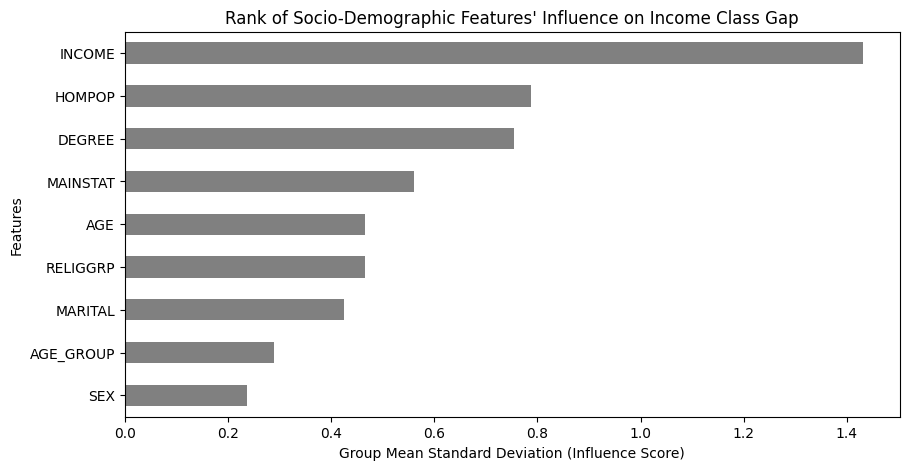

In [36]:
rank_df = pd.DataFrame(list(feat_influence.items()), columns=['Feature', 'Influence_Score'])
rank_df = rank_df.sort_values(by='Influence_Score', ascending=True)

rank_df.plot(kind='barh', x='Feature', y='Influence_Score', color='gray', legend=False, figsize=(10, 5))

plt.title('Rank of Socio-Demographic Features\' Influence on Income Class Gap')
plt.xlabel('Group Mean Standard Deviation (Influence Score)')
plt.ylabel('Features')
plt.show()

### **Since income's group mean has the highest standard deviation at 1.4309, it has the most influence on the income class gap compared to the other features. Conversely, sex has the least influence, with a score of 0.2368.**

## **Correlation of Features with Income Class Gap**

Convert the features to numerical values for gap correlation.

In [37]:
features = ['SEX', 'AGE', 'MARITAL', 'DEGREE', 'MAINSTAT', 'HOMPOP', 'RELIGGRP', 'INCOME', 'AGE_GROUP']
eda2_df[features + ['GAP']] = (eda2_df[features + ['GAP']].apply(pd.to_numeric, errors='coerce'))
corr_with_gap = (eda2_df[features + ['GAP']].corr(method='pearson')['GAP'].drop('GAP').dropna())

Using a bar graph, we can visualize the correlation values of each feature side by side. It is notable that this was only applied to numerical values.

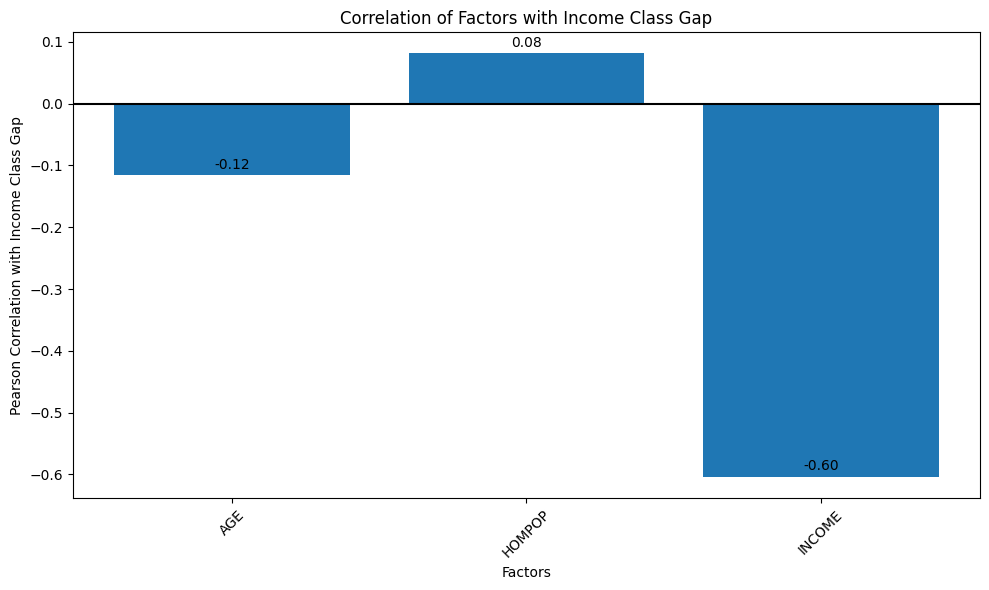

In [38]:
plt.figure(figsize=(10, 6))
plt.bar(corr_with_gap.index, corr_with_gap.values)

for i, value in enumerate(corr_with_gap.values):
    plt.text(i, value + 0.01, f'{value:.2f}', ha='center')

plt.axhline(0, color='black')
plt.xlabel('Factors')
plt.ylabel('Pearson Correlation with Income Class Gap')
plt.title('Correlation of Factors with Income Class Gap')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### **There is strong negative correlation between the gap and income where the lower the objective rank, the lower the income. It is notable that the lower class income is denoted as 3 and the higher is 1, thus the negative correlation. Age has  a negative correlation meaning the older the person is, the lower the perceived gap is. For home population, it has a positive correlation where the number of people is proportional to the gap they perceive and experience.**

## **Income-Class Gap Across Socio-Demographic Intersections**

### Make a new copy of Q1 dataframe


In [39]:
research_q3 = research_q1.copy()

### Prepare Variables Needed for Analysis

Based on the results of the previous exploratory data analysis (EDA), the socio-demographic variables with the highest influence on the income-class gap were selected. These variables will be used to examine how the magnitude and direction of the income-class gap vary across different socio-demographic intersections.

- DEGREE → Educational attainment
- HOMPOP → Household population size
- MAINSTAT → Employment or main activity status

In [40]:
research_q3['DEGREE'] = new_df['DEGREE']
research_q3['HOMPOP'] = new_df['HOMPOP']
research_q3['MAINSTAT'] = new_df['MAINSTAT']

### Clean and Categorize Household Population

In [41]:
# Convert HOMPOP to numeric values
research_q3['HOMPOP_NUM'] = pd.to_numeric(
    research_q3['HOMPOP'],
    errors='coerce'
)

# Replace invalid codes with missing values
research_q3['HOMPOP_NUM'] = research_q3['HOMPOP_NUM'].replace(-1, np.nan)

# Group household sizes
research_q3['HOMPOP_GROUPS'] = research_q3['HOMPOP_NUM'].apply(
    lambda x: '6+' if x >= 6
    else (str(int(x)) if pd.notnull(x) else np.nan)
)

### Compute the Income-Class Gap

In [42]:
# Calculate subjective class perception minus objective income level
research_q3['income_class_gap'] = (
    research_q3['TOPBOT'] - research_q3['INCOME']
)

# Ensure the gap is numeric so heatmaps can render correctly
research_q3['income_class_gap'] = pd.to_numeric(
    research_q3['income_class_gap'],
    errors='coerce'
)

The income-class gap measures the difference between:
- TOPBOT = perceived social class position
- INCOME = objective income category

Interpretation:
- Positive values → respondents perceive themselves as belonging to a higher social class than their income level suggests.
- Negative values → respondents perceive themselves as belonging to a lower social class than their income level suggests.
Values near zero → subjective and objective positions are closely aligned.

### Clean the Dataset

In [43]:
clean_df = research_q3.dropna(
    subset=[
        'income_class_gap',
        'INCOME',
        'DEGREE',
        'HOMPOP_GROUPS',
        'MAINSTAT'
    ]
).copy()

# Remove non-substantive responses
clean_df = clean_df[
    ~clean_df['DEGREE']
    .astype(str)
    .str.lower()
    .str.contains('no answer')
]

clean_df = clean_df[
    ~clean_df['MAINSTAT']
    .astype(str)
    .str.lower()
    .str.contains('no answer')
]

### **Heatmap 1: Income Level × Educational Attainment**

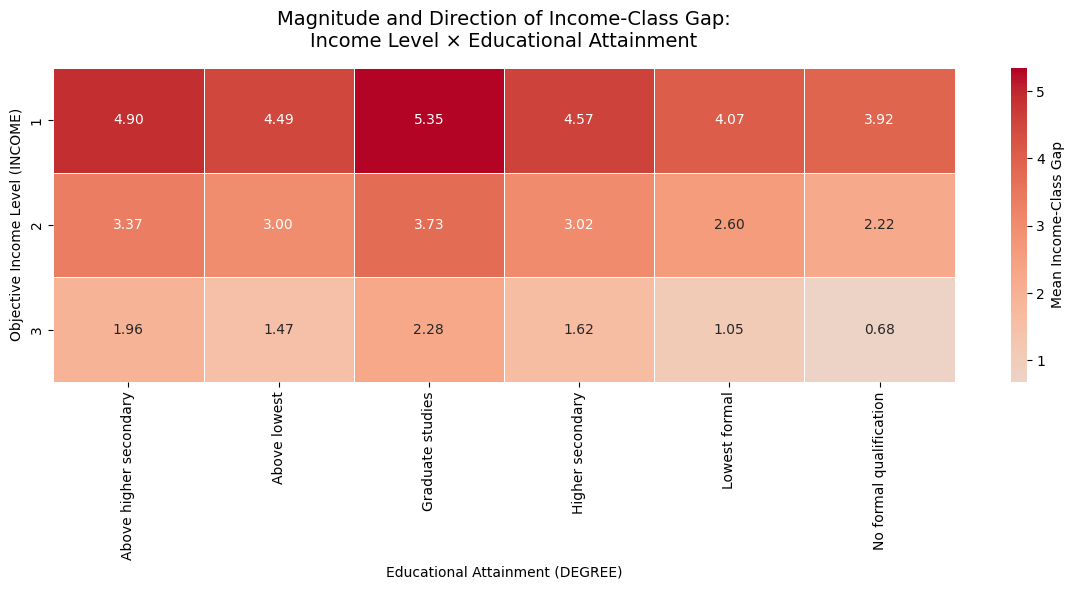

In [44]:
pivot_inc_deg = clean_df.pivot_table(
    values='income_class_gap',
    index='INCOME',
    columns='DEGREE',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot_inc_deg,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Income-Class Gap'}
)

plt.title(
    'Magnitude and Direction of Income-Class Gap:\nIncome Level × Educational Attainment',
    fontsize=14,
    pad=15
)

plt.ylabel('Objective Income Level (INCOME)')
plt.xlabel('Educational Attainment (DEGREE)')

plt.tight_layout()
plt.show()

**Interpretation Guide**

- Red shades → positive income-class gap
- Blue shades → negative income-class gap
- Darker colos → larger magnitude of difference
- Values near zero → stronger alignment between income and perceived class


### **It is noticeable that people with lower attained education seemed to be more aware of their objective class than those who accomplished a higher secondary degree and graduate studies. This can be an effect of social comparison and Bourdieu's Theory where people associate acquiring a higher degree to be a big advantage in securing a career and a stable income.**

### **Heatmap 2: Income Level × Household Population**


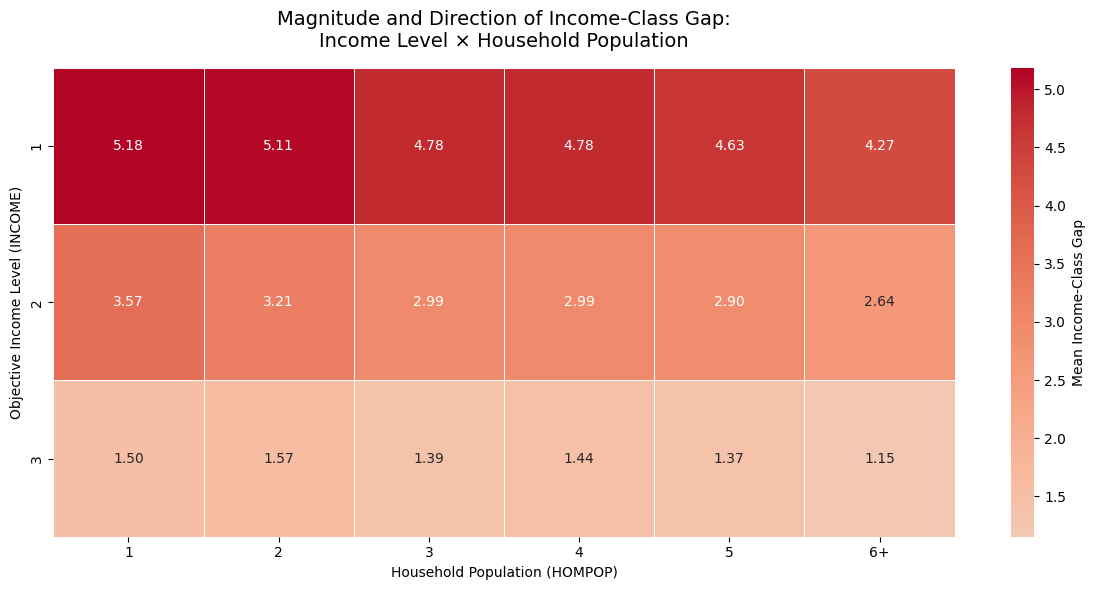

In [45]:
pivot_inc_pop = clean_df.pivot_table(
    values='income_class_gap',
    index='INCOME',
    columns='HOMPOP_GROUPS',
    aggfunc='mean'
)

pop_order = ['1', '2', '3', '4', '5', '6+']

existing_order = [
    col for col in pop_order
    if col in pivot_inc_pop.columns
]

pivot_inc_pop = pivot_inc_pop.reindex(
    columns=existing_order
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot_inc_pop,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Income-Class Gap'}
)

plt.title(
    'Magnitude and Direction of Income-Class Gap:\nIncome Level × Household Population',
    fontsize=14,
    pad=15
)

plt.ylabel('Objective Income Level (INCOME)')
plt.xlabel('Household Population (HOMPOP)')

plt.tight_layout()
plt.show()

### **The class gap is inversely proportional to the number of people in the household. This is true for Higher and Middle class households. People living in lower counts may be deluded that the lower amount of people to provide for, the lower the cost of living.**

### **Heatmap 3: Income Level × Employment Status**

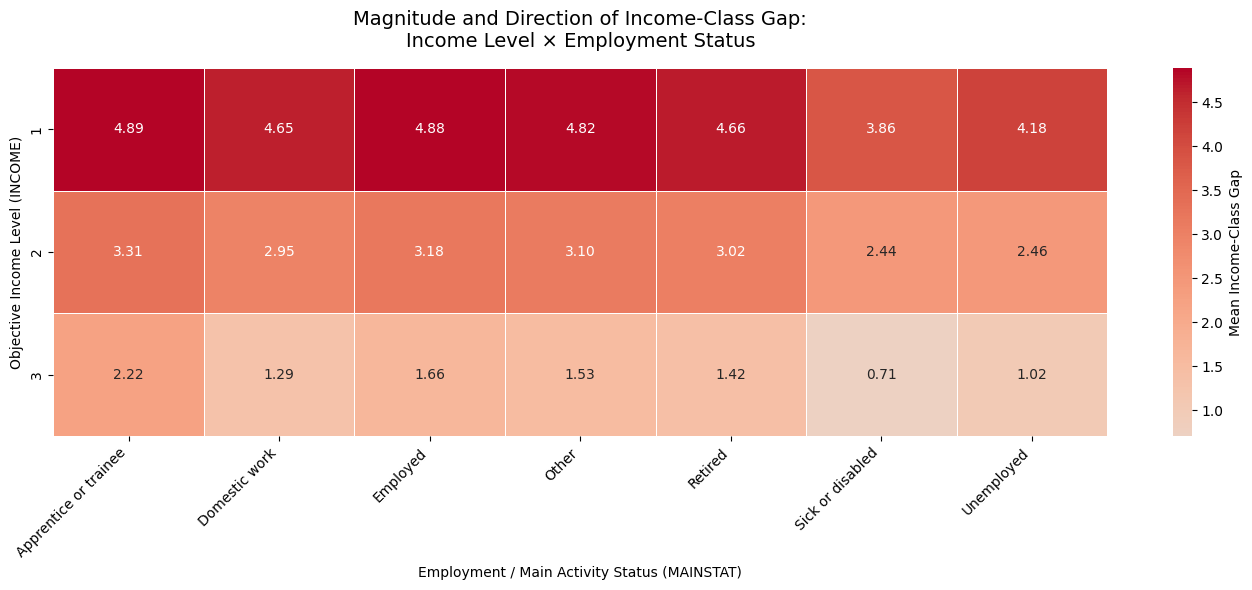

In [46]:
pivot_inc_stat = clean_df.pivot_table(
    values='income_class_gap',
    index='INCOME',
    columns='MAINSTAT',
    aggfunc='mean'
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    pivot_inc_stat,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Income-Class Gap'}
)

plt.title(
    'Magnitude and Direction of Income-Class Gap:\nIncome Level × Employment Status',
    fontsize=14,
    pad=15
)

plt.ylabel('Objective Income Level (INCOME)')
plt.xlabel('Employment / Main Activity Status (MAINSTAT)')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### **The discrepancy between the unemployment and the high gap of ranking themselves high may be influenced by their lifestyle and educational attainment. Additionally, those who are employed may experience an overestimation and underestimation of their rank based on Social Comparison Theory and Relative Depravation Theory respectively.**

# **REFERENCES**

[1] Butts, R. (2020). Social Comparison Theory. EBSCO. Retrieved June 20, 2026, from https://www.ebsco.com/research-starters/psychology/social-comparison-theory

[2] Claridge, T. (2015). Bourdieu on social capital – theory of capital. Institute for Social Capital. Retrieved June 20, 2026, from https://www.socialcapitalresearch.com/bourdieu-on-social-capital-theory-of-capital/

[3] Flynn, S. I. (2023). Social Movement Theory: Relative Deprivation Theory. EBSCO. Retrieved June 20, 2026, from https://www.ebsco.com/research-starters/social-sciences-and-humanities/social-movement-theory-relative-deprivation-theory

[4] Stanford University. (n.d.). MacArthur Scale of Subjective Social Status – Adult Version. Stanford SPARQtools. Retrieved June 20, 2026, from https://sparqtools.org/mobility-measure/macarthur-scale-of-subjective-social-status-adult-version/